In [1]:
import numpy as np
import matplotlib.pyplot as plt

### 1. Define constants

In [2]:
# Stoke's Law correction factor
b = 6.17e-6      # m(cmHg)
b_err = 1e-8      # m(cmHg)

# voltage applied to the capacitor
V = 400.5
V_err = np.sqrt(0.8**2. + 0.16**2.)

# distance between capacitor plates
d = 4.44e-3      # m
d_err = 0.02e-3  # m

## we assume these values have no uncertainties

# accepted electron charge
e = 1.602176634e-19      # C

# gravitational acceleration in Columbus, OH
g = 9.801      # m / s^2

# Density of Nye Lubricants Watch Oil 140C
rho = 0.86e3      # kg/m^3

# Viscosity of air (at T = 20° C)
eta = 18.13e-6      # N s / m^2

# atmospheric pressure at sea level
P = 76.      # cmHg

## 2. write out derivatives for error analysis

In [3]:
def dq_dd(v_E, v_g, a):
    term1 = (6. * np.pi / V) * np.sqrt((9. * eta**3.) / (2. * rho * g))
    term2 = (v_E + v_g) * np.sqrt(v_g) * pow(1 + b / (a * P), -1.5)
    return term1 * term2

def dq_dV(v_E, v_g, a):
    term1 = 9. * np.sqrt(2.) * np.pi * d * (v_E + v_g) * np.sqrt(v_g) * np.sqrt(eta**3. / (rho * g))
    term2 = V * V * pow(1 + b / (a * P), 1.5)
    return term1 / term2

def dq_dvE(v_E, v_g, a):
    term1 = 9. * np.sqrt(2.) * np.pi * d * np.sqrt(v_g) * np.sqrt(eta**3. / (rho * g))
    term2 = V * pow(1 + b / (a * P), 1.5)
    return term1 / term2

def dq_dvg(v_E, v_g, a):
    term1 = (9. * np.pi * d / (np.sqrt(2.) * V)) * np.sqrt(eta**3. / (rho * g))
    term2 = (3. * v_g + v_E) / np.sqrt(v_g) * pow(1 + b / (a * P), -1.5)
    return term1 * term2

def dq_da(v_E, v_g, a):
    term1 = (27. * np.pi * b * d) * (v_g + v_E) * np.sqrt(eta**3. / (rho * g))
    term2 = np.sqrt(2.) * V * P * a * a * pow(1 + b / (a * P), 2.5)
    return term1 / term2

def dq_db(v_E, v_g, a):
    term1 = (-27. * np.pi * d) * np.sqrt(v_g) * (v_g + v_E) * np.sqrt(eta**3. / (rho * g))
    term2 = np.sqrt(2.) * P * V * a * pow(1 + b / (a * P), 2.5)
    return term1 / term2

In [4]:
## final error equation

def calc_err(v_E, v_g, a, vE_err, vg_err, a_err):
    d_dep = (dq_dd(v_E, v_g, a))**2. * (d_err * d_err)
    V_dep = (dq_dV(v_E, v_g, a))**2. * (V_err * V_err)
    vE_dep = (dq_dvE(v_E, v_g, a))**2. * (vE_err * vE_err)
    vg_dep = (dq_dvg(v_E, v_g, a))**2. * (vg_err * vg_err)
    a_dep = (dq_da(v_E, v_g, a))**2. * (a_err * a_err)
    b_dep = (dq_db(v_E, v_g, a))**2. * (b_err * b_err)
    
    print(' d contribution: ', d_dep, '\n V contr: ', V_dep, '\n vE contr: ', vE_dep)
    print(' vg contr: ', vg_dep, '\n b contr: ', b_dep, '\n a contr: ', a_dep, '\n')
    return np.sqrt(d_dep + V_dep + vE_dep + vg_dep + a_dep + b_dep)

### 3. Read in Data

In [5]:
import pandas as pd

In [6]:
df = pd.read_csv('../../data/millikan_data/final_drop_data_please.csv')
df.head()

,Unnamed: 0,q,electrons,a,a_err_mean,a_err_std,VG,VE,VE_err_std,VE_err_mean,VG_err_mean,VG_err_std,Particle
0,0,1.098940e-18,6.859802,1.192191e-06,9.790200e-08,1.059863e-09,0.000147,0.000122,6.839727e-07,0.000043,0.000024,2.610863e-07,t10_p1.csv
1,1,3.136071e-19,1.957597,8.464405e-07,6.638142e-08,4.830039e-09,0.000074,0.000038,1.229005e-06,0.000021,0.000012,8.447644e-07,t10_p2.csv
2,2,3.220296e-19,2.010172,8.050844e-07,7.778765e-08,1.237340e-08,0.000067,0.000055,3.444008e-07,0.000024,0.000013,2.058348e-06,t10_p3.csv
3,3,3.079144e-19,1.922063,8.896929e-07,8.453861e-08,4.369005e-09,0.000082,0.000022,2.886441e-06,0.000027,0.000016,8.031769e-07,t10_p4.csv
4,4,9.272984e-19,5.788380,1.175841e-06,4.248735e-07,6.046406e-09,0.000143,0.000087,6.886051e-07,0.000013,0.000103,1.469043e-06,t10_p5.csv


### 4. Calculate error for each particle

In [7]:
err_vals = np.zeros(len(df))
i=0
for row in df.itertuples():
    err_vals[i] = calc_err(row.VE, row.VG, row.a, row.VE_err_std, row.VG_err_std, row.a_err_std)
    i+=1

# add calculated errors to dataframe
df['q_err'] = err_vals

 d contribution:  2.450429330290352e-41 
 V contr:  5.011369245764781e-42 
 vE contr:  7.83242114417411e-42
 vg contr:  4.1831039339586027e-42 
 b contr:  2.9012882000574594e-44 
 a contr:  5.944557557343878e-41 

 d contribution:  1.995564362119462e-42 
 V contr:  4.081125600583932e-43 
 vE contr:  1.1801341050616812e-41
 vg contr:  1.7229267601173582e-41 
 b contr:  4.4522792016530246e-45 
 a contr:  7.45606638659608e-40 

 d contribution:  2.1041928465301372e-42 
 V contr:  4.30328154658919e-43 
 vE contr:  8.271763843217518e-43
 vg contr:  1.0784762159787932e-40 
 b contr:  5.142994627933152e-45 
 a contr:  6.906212797449207e-39 

 d contribution:  1.923774422232732e-42 
 V contr:  3.93430810519383e-43 
 vE contr:  7.284367494725797e-41
 vg contr:  1.5108516368871917e-41 
 b contr:  3.918203070505173e-45 
 a contr:  4.398488713285077e-40 

 d contribution:  1.7447496360333046e-41 
 V contr:  3.568184790924198e-42 
 vE contr:  7.702121221249606e-42
 vg contr:  1.1425472982937489e-40

In [8]:
len(err_vals)

45

In [9]:
df.q_err

0     1.005016e-20
1     2.787553e-20
2     8.377009e-20
3     2.302438e-20
4     4.045840e-20
5     4.115954e-20
6     4.669960e-20
7     1.464245e-20
8     4.115081e-20
9     1.764481e-20
10    4.313880e-20
11    1.888732e-20
12    1.070821e-19
13    6.564870e-20
14    1.219964e-19
15    6.285919e-20
16    8.695310e-20
17    1.384319e-19
18    1.914430e-19
19    1.092533e-19
20    1.521242e-19
21    4.530525e-20
22    6.893727e-20
23    6.500619e-20
24    7.311234e-20
25    5.747334e-20
26    5.716619e-20
27    4.295382e-20
28    4.295382e-20
29    5.591700e-20
30    3.054037e-19
31    4.993530e-19
32    6.906880e-20
33    6.906880e-20
34    1.726228e-19
35    1.106511e-18
36    5.076367e-20
37    3.192745e-20
38    3.457630e-20
39    3.457630e-20
40    3.843022e-20
41    2.147400e-20
42    4.910548e-20
43    3.623246e-20
44    4.224605e-20
Name: q_err, dtype: float64

In [10]:
# sort data frame by increasing charge for better plotting
new_df = df.sort_values('q')
new_df['num'] = np.arange(0,len(new_df),1)

### 5. Plot the data

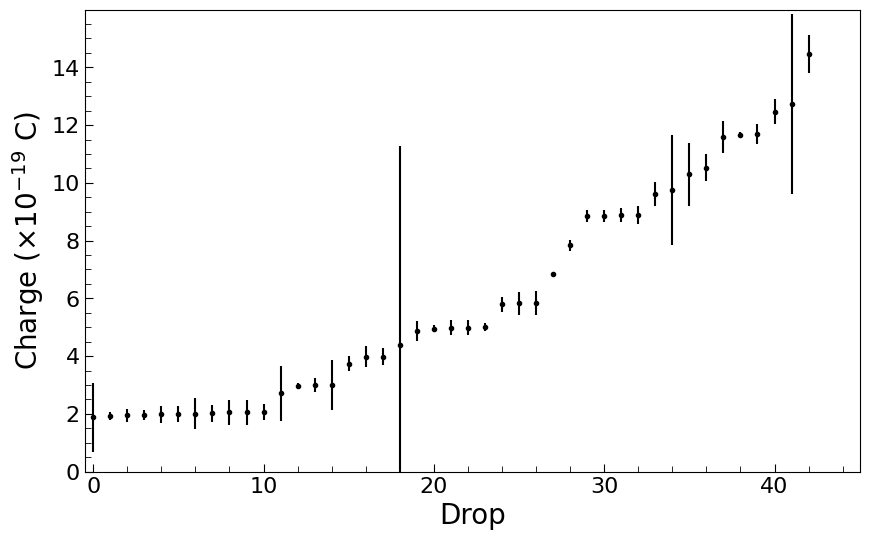

In [11]:
fig = plt.figure(figsize=(10,6))

plt.plot(new_df.num, new_df.q / e, '.k')
plt.errorbar(new_df.num, new_df.q / e, yerr = new_df.q_err / e, ls='none', c='k')
#plt.grid()

plt.ylim(0,16)
plt.xlim(-0.5,45)
plt.yticks(np.arange(0,16,2), fontsize=16)
plt.xticks(fontsize=16)

plt.xlabel('Drop', fontsize=20)
plt.ylabel(r'Charge ($ \times 10^{-19}$ C)', fontsize=20)

ax = fig.gca()
ax.minorticks_on()
ax.tick_params(direction='in', which='major', length=6)
ax.tick_params(direction='in', which='minor', length=4)

# plt.savefig('Millikan_plateaus2.pdf',bbox_inches='tight')

In [12]:
new_df.head()

,Unnamed: 0,q,electrons,a,a_err_mean,a_err_std,VG,VE,VE_err_std,VE_err_mean,VG_err_mean,VG_err_std,Particle,q_err,num
18,18,3.014149e-19,1.881491,7.144285e-07,2.294084e-07,2.143611e-08,0.000053,0.000078,2.892998e-06,0.000026,0.000034,3.164413e-06,\t4_p4.csv,1.914430e-19,0
3,3,3.079144e-19,1.922063,8.896929e-07,8.453861e-08,4.369005e-09,0.000082,0.000022,2.886441e-06,0.000027,0.000016,8.031769e-07,t10_p4.csv,2.302438e-20,1
43,43,3.128891e-19,1.953116,8.277219e-07,1.223303e-07,5.862267e-09,0.000071,0.000044,2.335806e-06,0.000027,0.000021,1.002625e-06,\t9_p8.csv,3.623246e-20,2
1,1,3.136071e-19,1.957597,8.464405e-07,6.638142e-08,4.830039e-09,0.000074,0.000038,1.229005e-06,0.000021,0.000012,8.447644e-07,t10_p2.csv,2.787553e-20,3
21,21,3.172343e-19,1.980239,8.813396e-07,1.717464e-07,8.770665e-09,0.000080,0.000028,3.220276e-07,0.000019,0.000031,1.597219e-06,\t6_p1.csv,4.530525e-20,4


In [ ]:
# there is significant error on some points, so let's sigma clip (remove points with error above a certain value)
print(len(new_df))
new_df.drop(new_df[(new_df.q_err > 2*e) | (new_df.q > 9.5*e)].index, inplace=True)
print(len(new_df))
new_df = new_df.reset_index()
new_df = new_df.reset_index()

45
43


In [14]:
new_df.head()

,level_0,index,Unnamed: 0,q,electrons,a,a_err_mean,a_err_std,VG,VE,VE_err_std,VE_err_mean,VG_err_mean,VG_err_std,Particle,q_err,num
0,0,18,18,3.014149e-19,1.881491,7.144285e-07,2.294084e-07,2.143611e-08,0.000053,0.000078,2.892998e-06,0.000026,0.000034,3.164413e-06,\t4_p4.csv,1.914430e-19,0
1,1,3,3,3.079144e-19,1.922063,8.896929e-07,8.453861e-08,4.369005e-09,0.000082,0.000022,2.886441e-06,0.000027,0.000016,8.031769e-07,t10_p4.csv,2.302438e-20,1
2,2,43,43,3.128891e-19,1.953116,8.277219e-07,1.223303e-07,5.862267e-09,0.000071,0.000044,2.335806e-06,0.000027,0.000021,1.002625e-06,\t9_p8.csv,3.623246e-20,2
3,3,1,1,3.136071e-19,1.957597,8.464405e-07,6.638142e-08,4.830039e-09,0.000074,0.000038,1.229005e-06,0.000021,0.000012,8.447644e-07,t10_p2.csv,2.787553e-20,3
4,4,21,21,3.172343e-19,1.980239,8.813396e-07,1.717464e-07,8.770665e-09,0.000080,0.000028,3.220276e-07,0.000019,0.000031,1.597219e-06,\t6_p1.csv,4.530525e-20,4


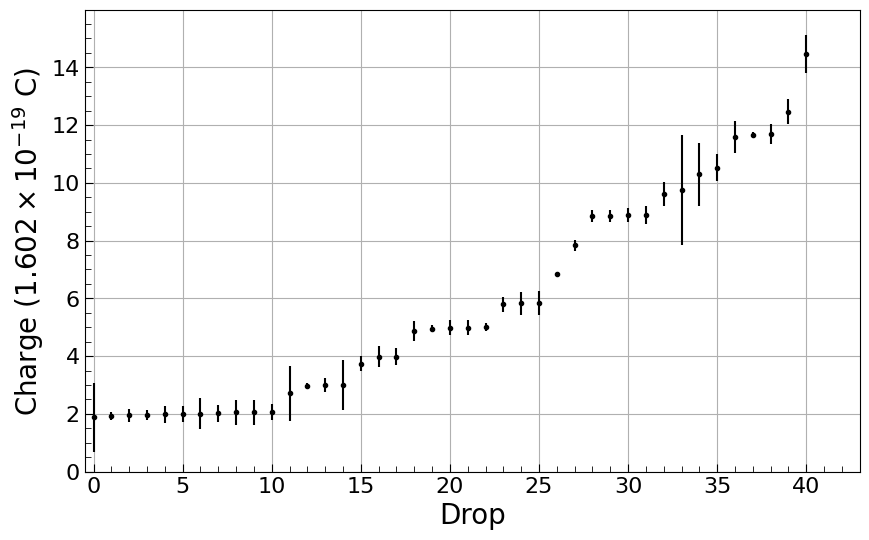

In [15]:
fig = plt.figure(figsize=(10,6))

plt.plot(new_df.level_0, new_df.q / e, '.k')
plt.errorbar(new_df.level_0, new_df.q / e, yerr = new_df.q_err / e, ls='none', c='k')
plt.grid()

plt.ylim(0,16)
plt.xlim(-0.5,43)
plt.yticks(np.arange(0,16,2), fontsize=16)
plt.xticks(fontsize=16)

plt.xlabel('Drop', fontsize=20)
plt.ylabel(r'Charge ($ 1.602 \times 10^{-19}$ C)', fontsize=20)

ax = fig.gca()
ax.minorticks_on()
ax.tick_params(direction='in', which='major', length=6)
ax.tick_params(direction='in', which='minor', length=4)

## 6. Estimate $e$ from weighted average of plateau separation

In [16]:
# sort drops by rounding to nearest integer
cutoffs = np.arange(0.5, 15, 1)

my_plateaus = [[] for i in range(len(cutoffs))]
my_charge_errs = [[] for i in range(len(cutoffs))]

for i in range(len(new_df)):
    
    this_q = new_df.q[i] / e # get integer of e
    this_q_err = new_df.q_err[i] / e
    
    # sort into correponding bin
    for j in range(len(cutoffs)):
        if (cutoffs[j-1] < this_q) and (this_q < cutoffs[j]):
            my_plateaus[j].append(this_q)
            my_charge_errs[j].append(this_q_err)

In [17]:
plateau_avgs = []
plateau_stds = []

# take the weighted average of each plateau
for i in range(len(my_plateaus)):
    
    # get rid of ones without any drops
    if len(my_plateaus[i]) > 0:
        plateau_avgs.append(np.average(my_plateaus[i], weights=my_charge_errs[i]))
        plateau_stds.append(np.std(my_plateaus[i]))

In [18]:
# we don't have measurements for every integer of e
# just the ones in this list
plateaus = [2,3,4,5,6,7,8,9,10,11,12,13,14]

# calculate the difference between each plateau
measurements = []
measurement_uncertainties = []
for i in range(len(plateau_avgs)):
    for j in np.arange(i,len(plateau_avgs),1):
        if i != j:
            meas = np.abs((plateau_avgs[j]-plateau_avgs[i])/(plateaus[j]-plateaus[i])) * e
            meas_err = np.sqrt((plateau_stds[j])**2. + (plateau_stds[i])**2.)
            measurements.append(meas)
            measurement_uncertainties.append(meas_err)
    

In [19]:
len(measurements)

66

In [20]:
# take the mean and standard deviation of all the plateau differences 
e_guess = np.average(measurements, weights=measurement_uncertainties)
e_guess_uncertainty = np.std(measurements)

print('The estimated electron charge is', e_guess, '+/-', e_guess_uncertainty, 'C')
print('This is', round(e_guess/e,3), '+/-', round(e_guess_uncertainty/e,3), 'of the accepted literature value')

The estimated electron charge is 1.7239946217361146e-19 +/- 4.085925824182893e-20 C
This is 1.076 +/- 0.255 of the accepted literature value


In [21]:
model = round(new_df.q / e_guess) * e_guess
data = np.array(new_df.q)
data_err = np.array(new_df.q_err)

N = len(model)

Red_Chi_sq_linear= 1.0/(N-2)*np.sum((data-model)**2/data_err**2)
print('Reduced Chi Squared= ', Red_Chi_sq_linear)

Reduced Chi Squared=  2.608766485348295


## 7. Show charge is quantized

Show that the error bars do not overlap between weighted average and uncertainty for each plateau

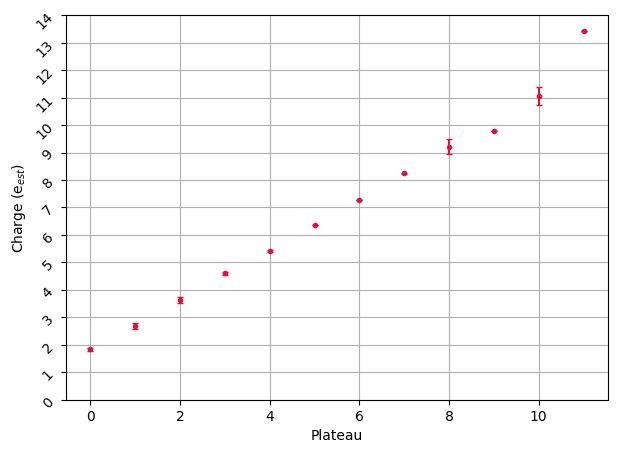

In [22]:
fig = plt.figure(figsize=(7,5))

plt.plot(range(len(plateau_avgs)), np.array(plateau_avgs)*e/e_guess, '.', c='crimson')
plt.errorbar(range(len(plateau_avgs)), np.array(plateau_avgs)*e/e_guess, yerr=np.array(plateau_stds)*e/e_guess, c='crimson', ls='none',capsize=2)

plt.grid()
plt.yticks(np.arange(0,15,1), rotation=45)


plt.xlabel('Plateau')
plt.ylabel('Charge (e$_{est}$)')

plt.show()

In [23]:
print(' Plateau #    Charge     Uncertainty \n')
print('----------------------------------------')
for i in range(len(plateau_avgs)):
    print(str(i)+'      '+ str(plateau_avgs[i]) +'     ' +str(plateau_stds[i]))

 Plateau #    Charge     Uncertainty 

----------------------------------------
0      1.975481566030555     0.05527234178053992
1      2.8757898021238892     0.11954399525754579
2      3.910326858627228     0.1179084441389592
3      4.94472521825536     0.04885531030739323
4      5.825500074343871     0.024839598897057943
5      6.8590453100073     0.0
6      7.831304338517285     0.0
7      8.878553735140086     0.021490346873603294
8      9.905359582106223     0.2920931129868113
9      10.527151946570335     0.0
10      11.887269362556173     0.3560660293302991
11      14.455185717462212     0.0


## 8. Estimate $e$ with iterative approach

In [24]:
## following the steps at end of Millikan README

e_wav = np.copy(e_guess)

#delta = 1

#while (delta > 0.05):

# get an integer guess based on our drop from above
int_guess = [round(new_df.q[i] / e_wav) for i in range(len(new_df))]

# then the new e charge guesses are:
new_e_guesses = new_df.q / int_guess

# get the weights from our uncertainties
# larger drops have larger uncertainties
e_guess_weights = (int_guess / new_df.q_err)**2.

#old_e_wav = np.copy(e_wav)
e_wav = np.sum(e_guess_weights * new_e_guesses) / np.sum(e_guess_weights)
#delta = abs(e_wav - old_e_wav) / e_wav
